In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv


In [4]:
#Loading Dataset

import pandas as pd

students = pd.read_csv(
    "/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv"
)

students.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


#Basic ExPloration of Data

In [5]:
students.shape

(1000, 12)

In [6]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [12]:
students.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [7]:
students.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [56]:
students.tail()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


In [15]:
students.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

In [18]:
#Checking for  missing values

students.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [20]:
#Checking for  duplicate rows

students.duplicated().sum()

np.int64(0)

In [48]:
#View of the  statistical summary

students.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [ ]:
Exploring the  categorical columns to find unique values:

In [28]:
students["gender"].value_counts()

gender
Female    510
Male      490
Name: count, dtype: int64

In [50]:
students["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [49]:
#Checking all unique values in every column

for column in students.columns:
    print(column)
    print(students[column].unique())
    print("----------------")

student_id
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195 

In [30]:
#Checking the  correlations between numerical variables

students.corr(numeric_only=True)

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
student_id,1.000000,0.027615,-0.044651,-0.012304,0.011917,0.025282
study_time_hours,0.027615,1.000000,-0.043712,0.005594,-0.035700,0.567513
attendance_percent,-0.044651,-0.043712,1.000000,0.034089,-0.014310,0.261872
sleep_hours,-0.012304,0.005594,0.034089,1.000000,0.000943,0.147811
previous_grade,0.011917,-0.035700,-0.014310,0.000943,1.000000,0.406327
final_exam_score,0.025282,0.567513,0.261872,0.147811,0.406327,1.000000


In [ ]:
# Sorting  students by performance by the Highest scores and Lowest Scores:

In [32]:
#Highest scores

students.sort_values(
    by="final_exam_score",
    ascending=False
).head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
381,382,Female,6.2,83.2,7.3,PhD,Yes,No,No,86.1,100.0,A
383,384,Male,6.2,90.5,6.6,High School,Yes,Yes,No,84.0,100.0,A
387,388,Male,5.0,86.9,4.9,NaN,Yes,Yes,No,100.0,100.0,A
312,313,Female,4.9,90.1,7.5,NaN,Yes,Yes,No,92.5,100.0,A
314,315,Male,2.7,88.5,7.3,Masters,Yes,Yes,No,99.3,100.0,A
315,316,Female,5.1,89.9,8.1,PhD,Yes,Yes,No,75.2,100.0,A
934,935,Female,3.6,89.4,7.0,Bachelors,Yes,No,No,95.3,100.0,A
42,43,Female,5.1,82.8,8.1,Bachelors,Yes,Yes,No,95.7,100.0,A
50,51,Male,5.9,82.5,6.6,Bachelors,Yes,Yes,No,66.5,100.0,A
948,949,Female,3.7,93.9,8.5,High School,No,No,No,93.0,100.0,A


In [33]:
#Lowest scores

students.sort_values(
    by="final_exam_score"
).head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
147,148,Male,1.7,83.5,5.7,Masters,Yes,Yes,Yes,59.2,46.8,F
760,761,Female,1.9,69.0,6.0,High School,Yes,No,Yes,34.5,53.2,F
715,716,Female,0.5,76.0,7.8,High School,No,Yes,No,62.5,54.1,F
539,540,Female,1.2,75.8,7.1,Bachelors,Yes,Yes,Yes,45.0,57.3,F
364,365,Male,2.1,58.0,8.9,Bachelors,Yes,Yes,No,61.5,57.4,F
790,791,Female,1.0,68.9,5.0,High School,Yes,Yes,No,77.6,57.6,F
807,808,Male,4.0,71.4,6.1,High School,No,Yes,Yes,49.1,57.8,F
608,609,Female,2.0,88.5,5.7,High School,No,Yes,Yes,63.7,58.6,F
279,280,Female,3.7,84.8,5.2,PhD,No,Yes,Yes,54.3,58.8,F
116,117,Male,1.4,76.8,6.4,NaN,No,Yes,No,76.6,59.3,F


#Filtering the  data

Students with scores above 90:

In [36]:
students[students["final_exam_score"] > 90]

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
13,14,Male,5.4,78.4,6.9,Bachelors,No,No,No,67.9,93.3,A
19,20,Male,4.4,77.4,8.4,Masters,No,No,Yes,77.0,92.8,A
...,...,...,...,...,...,...,...,...,...,...,...,...
980,981,Female,3.5,79.6,6.2,High School,Yes,Yes,No,90.9,91.4,A
985,986,Female,6.1,79.5,5.4,High School,Yes,No,No,75.6,96.4,A
989,990,Female,3.2,99.5,5.6,High School,Yes,No,Yes,78.0,93.9,A
993,994,Female,6.2,87.6,5.9,PhD,Yes,No,No,75.4,92.7,A


In [39]:
#Students with low attendance:

students[students["attendance_percent"] < 70]

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
39,40,Male,5.6,65.3,7.4,Masters,Yes,Yes,No,85.5,91.6,A
69,70,Female,2.3,67.4,8.6,High School,Yes,No,No,90.9,85.1,B
101,102,Female,1.9,67.4,6.7,Bachelors,Yes,Yes,Yes,75.5,66.3,D
102,103,Female,6.0,69.7,6.8,Bachelors,No,No,No,65.3,89.5,B
127,128,Male,2.1,66.3,6.5,High School,Yes,No,Yes,88.4,63.0,D
...,...,...,...,...,...,...,...,...,...,...,...,...
946,947,Male,3.2,69.8,8.7,Masters,Yes,No,No,43.1,70.4,C
958,959,Female,4.9,63.5,5.6,Bachelors,Yes,Yes,No,73.0,87.6,B
972,973,Male,1.3,67.2,7.3,Bachelors,Yes,No,No,79.0,84.1,B
976,977,Female,3.7,69.8,4.6,High School,No,Yes,No,72.5,80.9,B


**Visual exploration**

In [40]:
#Importing  visualization libraries:

import matplotlib.pyplot as plt
import seaborn as sns


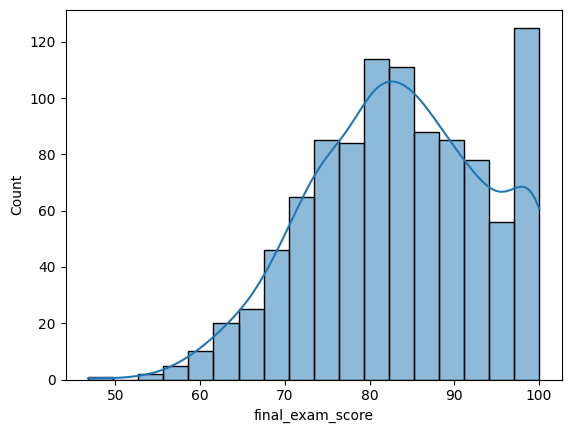

In [51]:
#Distribution of exam scores


sns.histplot(
    students["final_exam_score"],
    kde=True
)
plt.show()

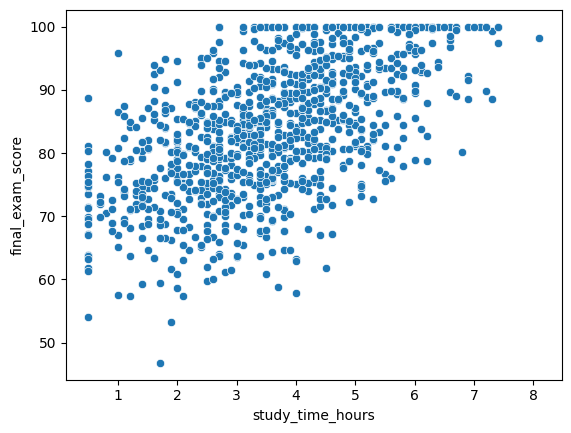

In [52]:
#Relationship between study hours and scores


sns.scatterplot(
    data=students,
    x="study_time_hours",
    y="final_exam_score"
)
plt.show()

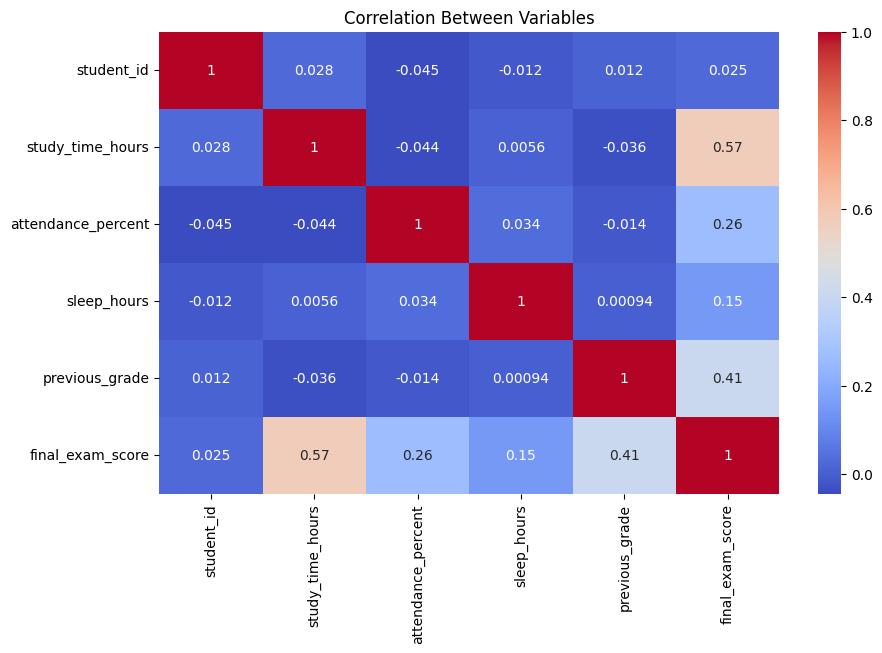

In [57]:
plt.figure(figsize=(10,6))

sns.heatmap(
    students.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Variables")
plt.show()

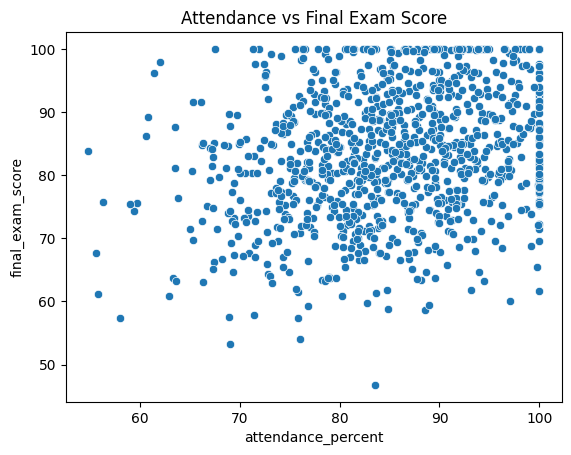

In [58]:
sns.scatterplot(
    data=students,
    x="attendance_percent",
    y="final_exam_score"
)

plt.title("Attendance vs Final Exam Score")
plt.show()

In [53]:
#Comparing the categories to see the average score by gender


students.groupby("gender")["final_exam_score"].mean()

gender
Female    83.606863
Male      83.477551
Name: final_exam_score, dtype: float64

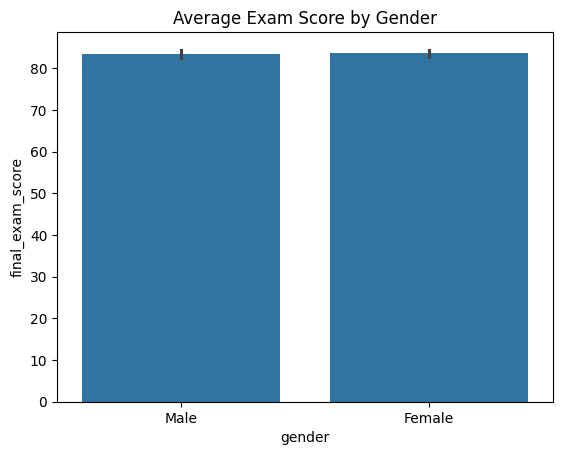

In [59]:
sns.barplot(
    data=students,
    x="gender",
    y="final_exam_score"
)

plt.title("Average Exam Score by Gender")
plt.show()

In [ ]:
## Key Findings

- Students with higher study hours generally achieved higher exam scores.
- Attendance showed a positive relationship with academic performance.
- The dataset contained no missing values or duplicate records.
- Study habits appear to influence final exam outcomes.